# Companies Stock Forecasting Model

## Importing

In [1]:
import mlflow
import dagshub
import os
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from prophet import Prophet
from utils import *

/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Loading Processed Data

In [2]:
data = joblib.load("../data/processed/processed_data.joblib")

In [3]:
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
X_train_sample = data["X_train_sample"]
y_train_sample = data["y_train_sample"]

## Model Implementation

### DagsHub

In [4]:
"""
Initializating DagsHub
"""
dagshub.init(repo_owner=REPOSITORY_OWNER, repo_name=REPOSITORY_NAME, mlflow=True)

Accessing as MaCh1Ne01

Initialized MLflow to track repo "MaCh1Ne01/mle-specialization-03"

Repository MaCh1Ne01/mle-specialization-03 initialized!

### MLflow

In [5]:
mlflow.set_tracking_uri(MLFLOW_DAGSHUB_URL)

In [6]:
setting_experiment()

Experiment Companies Stock Forecasting - MLE 03 Project already exists. Using existing one.
ID: 0


In [7]:
mlflow.autolog(disable=True,)

### Models

In [8]:
base_model = LinearRegression()

In [9]:
model_01 = LGBMRegressor(random_state=SEED, verbose=-1)
search_space_model_01 = {
    "learning_rate": Continuous(0.01, 0.3, distribution="uniform"),
    "n_estimators": Integer(100, 500), 
    "num_leaves": Integer(31, 127)
    }

In [10]:
model_02 = XGBRegressor(random_state=SEED, verbosity=0)
search_space_model_02 = {
    "learning_rate": Continuous(0.01, 0.3, distribution="log-uniform"),
    "max_depth": Integer(3, 10),
    "n_estimators": Integer(50, 300),
    "subsample": Continuous(0.6, 1.0)
    }

In [11]:
model_03 = RidgeModelStackingEnsemble(base_models=[base_model,model_01,model_02], alpha=1.0, random_state=SEED)

## Training

In [12]:
base_model_metrics, base_model = executing_and_saving_regression_model(model=base_model, model_name=BASE_MODEL_NAME, X=X_train, y=y_train, X_sample=None, y_sample=None,\
                                                                       X_test=X_test, y_test=y_test, label_data=TESTING_DATA_LABEL, search_space=None)

🏃 View run Linear Regression Model Run at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0/runs/a8e0f177b3da47aca3a20eb12475dfe0
🧪 View experiment at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0
**********Linear Regression Metrics (Testing Data):**********
Mean Absolute Error: 0.8269
Root Mean Squared Error: 2.4194
Square R: 1.0000
Mean Absolute Percentage Error: 0.5274
Symmetric Mean Absolute Percentage Error: 0.5268


In [13]:
model_01_metrics, model_01 = executing_and_saving_regression_model(model=model_01, model_name=MODEL_01_NAME, X=X_train, y=y_train, X_sample=X_train_sample, y_sample=y_train_sample,\
                                                         X_test=X_test, y_test=y_test, label_data=TESTING_DATA_LABEL, search_space=search_space_model_01)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	4     	-69.7549	2.8835     	-64.8688   	-71.9303   
1  	8     	-71.2114	0.212854   	-70.9985   	-71.4243   
2  	8     	-64.0263	6.64366    	-57.3868   	-70.9985   
3  	8     	-67.4689	5.82105    	-57.3866   	-70.8297   
4  	8     	-67.3128	5.73271    	-57.3866   	-70.8297   
🏃 View run LightGBM Regressor Model Run at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0/runs/139bad4a183849a8a8c89dc6cba6d504
🧪 View experiment at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0
**********LightGBM Regressor Metrics (Testing Data):**********
Mean Absolute Error: 7.9524
Root Mean Squared Error: 87.0047
Square R: 0.9378
Mean Absolute Percentage Error: 1.6892
Symmetric Mean Absolute Percentage Error: 1.6150


In [14]:
model_02_metrics, model_02 = executing_and_saving_regression_model(model=model_02, model_name=MODEL_02_NAME, X=X_train, y=y_train, X_sample=X_train_sample, y_sample=y_train_sample,\
                                                         X_test=X_test, y_test=y_test, label_data=TESTING_DATA_LABEL, search_space=search_space_model_02)

gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	4     	-76.912	1.19974    	-75.6675   	-78.8367   
1  	8     	-74.9355	0.300214   	-74.6374   	-75.2838   
2  	8     	-75.0524	0.718744   	-74.6374   	-76.2973   
3  	8     	-74.1809	0.405984   	-73.7749   	-74.5868   
4  	8     	-73.9707	0.355762   	-73.7606   	-74.5868   


/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/xgboost/sklearn.py:1115: UserWarning: [23:17:34] WARNING: /workspace/src/c_api/c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


🏃 View run XGBoost Regressor Model Run at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0/runs/8bbaa8cac46944c88b46cd12648745ec
🧪 View experiment at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0
**********XGBoost Regressor Metrics (Testing Data):**********
Mean Absolute Error: 8.6207
Root Mean Squared Error: 89.7513
Square R: 0.9338
Mean Absolute Percentage Error: 1.7880
Symmetric Mean Absolute Percentage Error: 1.8068


In [15]:
model_03 = RidgeModelStackingEnsemble(base_models=[base_model,model_01,model_02], alpha=1.0, random_state=SEED)
model_03_metrics, model_03 = executing_and_saving_regression_model(model=model_03, model_name=MODEL_03_NAME, X=X_train, y=y_train, X_sample=None, y_sample=None,\
                                                                   X_test=X_test, y_test=y_test, label_data=TESTING_DATA_LABEL, search_space=None)

/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


🏃 View run Ridge Stacking Ensemble Model Run at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0/runs/ca7e7908049d47849d32ae79a4cb49a9
🧪 View experiment at: https://dagshub.com/MaCh1Ne01/mle-specialization-03.mlflow/#/experiments/0
**********Ridge Stacking Ensemble Metrics (Testing Data):**********
Mean Absolute Error: 0.8268
Root Mean Squared Error: 2.4191
Square R: 1.0000
Mean Absolute Percentage Error: 0.5272
Symmetric Mean Absolute Percentage Error: 0.5266


## Predicting

In [16]:
"""
This section will be simulated with the same testing data
"""
base_model_predictions = predicting_regression_model(model=base_model, model_name=BASE_MODEL_NAME, X=X_test)

Linear Regression model: (120789 values were predicted.


In [17]:
model_01_predictions = predicting_regression_model(model=model_01, model_name=MODEL_01_NAME, X=X_test)

LightGBM Regressor model: (120789 values were predicted.


In [18]:
model_02_predictions = predicting_regression_model(model=model_02, model_name=MODEL_02_NAME, X=X_test)

XGBoost Regressor model: (120789 values were predicted.


In [19]:
model_03_predictions = predicting_regression_model(model=model_03, model_name=MODEL_03_NAME, X=X_test)

/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/marcos/mle-specialization-03/mles3-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Ridge Stacking Ensemble model: (120789 values were predicted.


## Visualizing

### Performance

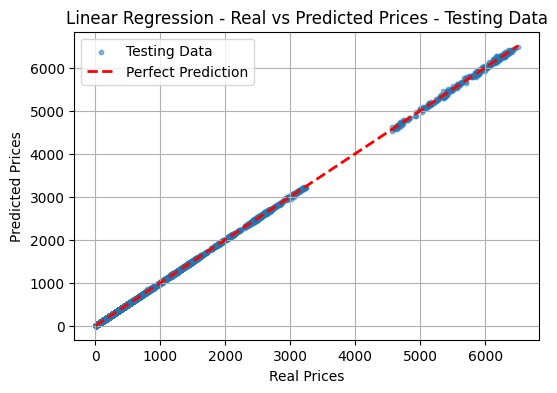

In [20]:
visualizing_regression_model_performance(model=base_model, model_name=BASE_MODEL_NAME, y=y_test, predictions=base_model_predictions, label_data=TESTING_DATA_LABEL)

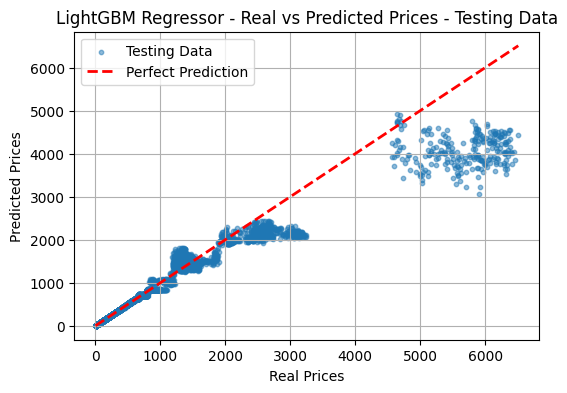

In [21]:
visualizing_regression_model_performance(model=model_01, model_name=MODEL_01_NAME, y=y_test, predictions=model_01_predictions, label_data=TESTING_DATA_LABEL)

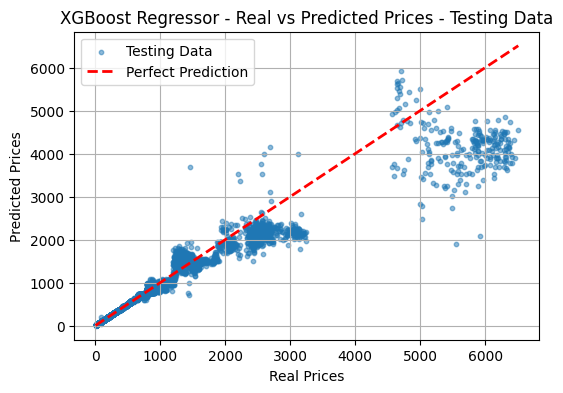

In [22]:
visualizing_regression_model_performance(model=model_02, model_name=MODEL_02_NAME, y=y_test, predictions=model_02_predictions, label_data=TESTING_DATA_LABEL)

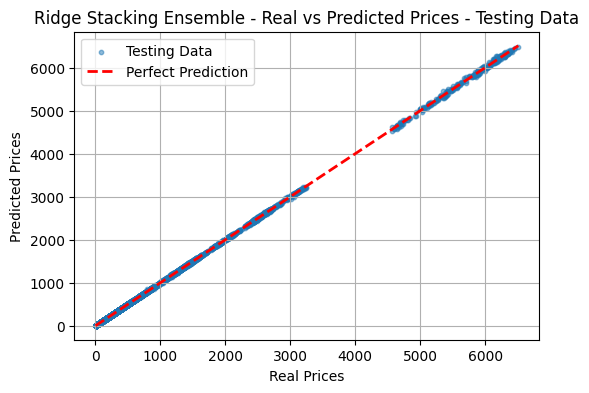

In [23]:
visualizing_regression_model_performance(model=model_03, model_name=MODEL_03_NAME, y=y_test, predictions=model_03_predictions, label_data=TESTING_DATA_LABEL)

### Temporal Serie for Apple - Prophet

In [2]:
ts_data = joblib.load("../data/processed/ts_data.joblib")
ts_X_train = ts_data["X_train"]
ts_y_train = ts_data["y_train"]
ts_X_test = ts_data["X_test"]
ts_y_test = ts_data["y_test"]

In [3]:
prophet_model = Prophet(yearly_seasonality=True, daily_seasonality=True)
ts_training_data, ts_testing_data, ts_training_prophet, ts_testing_prophet = preparing_prophet_datasets(X_train=ts_X_train, y_train=ts_y_train, X_test=ts_X_test, y_test=ts_y_test,\
                                                                                                        temporal_feature="Date", target=TARGET, objective_feature=STRATIFY_FEATURE, objective_value="AAPL")             
prophet_model.fit(ts_training_prophet)
prophet_predictions = prophet_model.predict(ts_testing_prophet)
prophet_y_pred = prophet_predictions["yhat"].values

printing_regression_model_metrics(model_name="Prophet", real=ts_testing_prophet["y"], predictions=prophet_y_pred, label_data=TESTING_DATA_LABEL)

02:32:08 - cmdstanpy - INFO - Chain [1] start processing
02:32:09 - cmdstanpy - INFO - Chain [1] done processing


**********Prophet Metrics (Testing Data):**********
Mean Absolute Error: 35.9858
Root Mean Squared Error: 40.8495
Square R: -3.7704
Mean Absolute Percentage Error: 20.6634
Symmetric Mean Absolute Percentage Error: 23.3684


In [4]:
future_data = prophet_model.make_future_dataframe(periods=len(ts_testing_prophet), include_history=True)
prophet_forecast = prophet_model.predict(future_data)

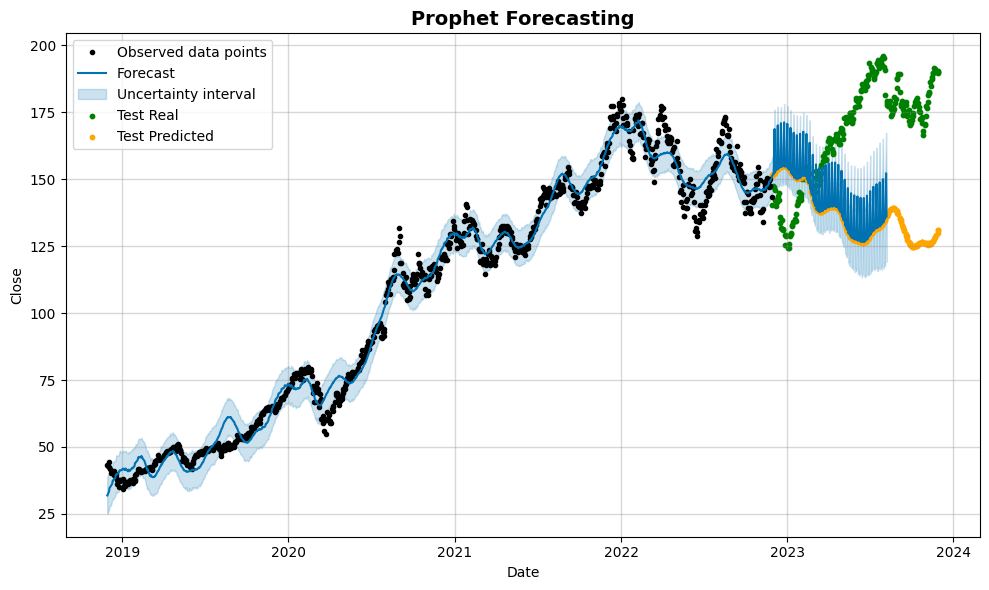

In [5]:
graphing_temporal_serie(model=prophet_model, model_name="Prophet", predictions_detail=prophet_forecast, X_test=ts_testing_prophet["ds"], y_test=ts_testing_prophet["y"],\
                        y_pred=prophet_y_pred, temporal_feature="Date", target=TARGET)

/home/marcos/mle-specialization-03/notebooks/utils.py:871: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


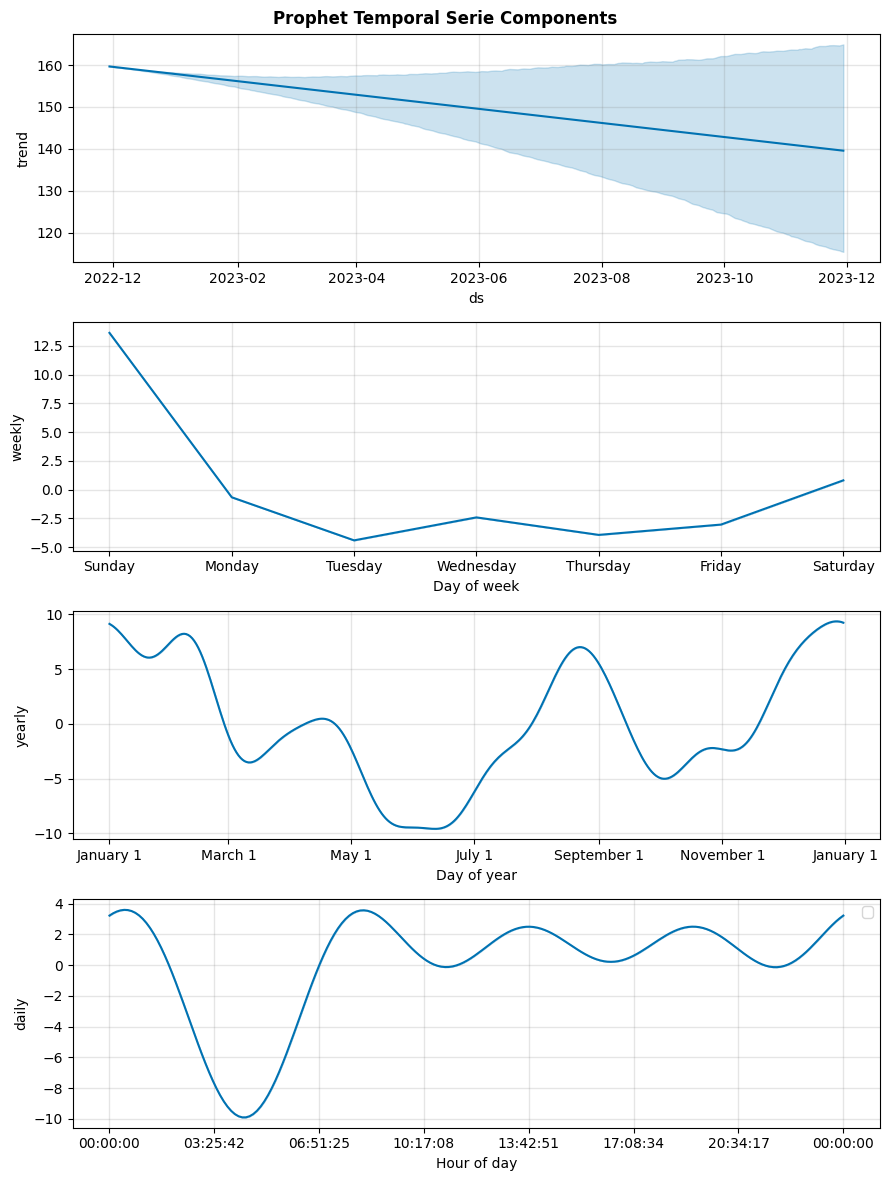

In [6]:
graphing_temporal_series_components(model=prophet_model, model_name="Prophet", predictions_detail=prophet_predictions)

## Results

### Silhouette, Calinski-Harabasz and Davies-Bouldin Score

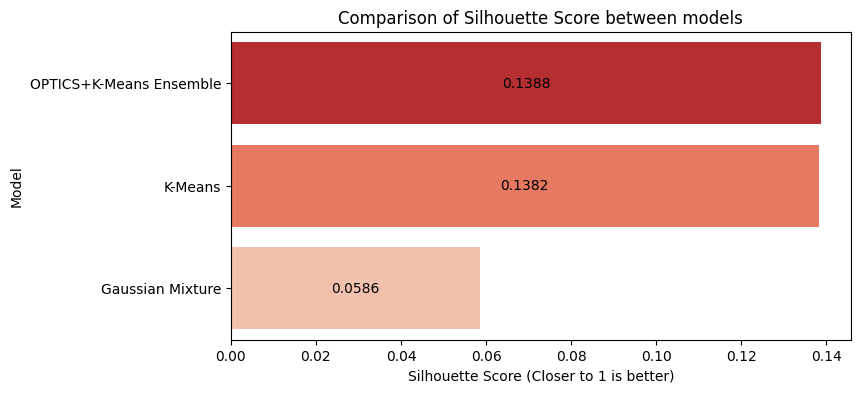

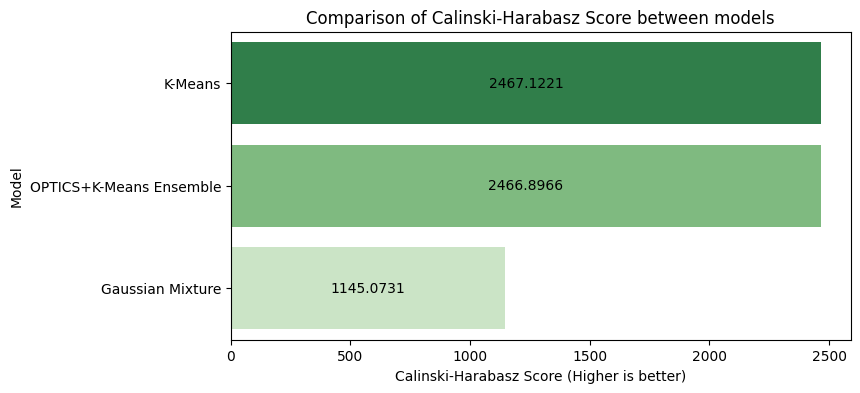

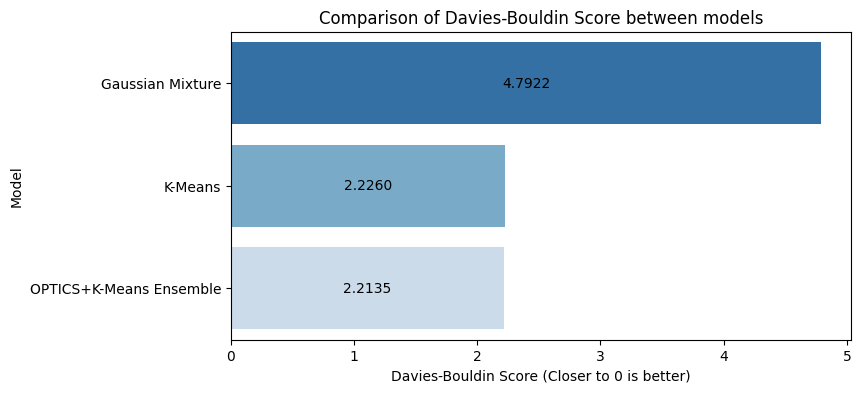

In [23]:
graphing_clustering_models_results(base_model_metrics=base_model_metrics, model_01_metrics=model_01_metrics, model_02_metrics=model_02_metrics)